# Smearing Matrix and Effective Area

The tutorial shows how to access instrument response functions in the form of smearing matrices and effective areas from IceCube 14-year public data release. 

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

For analysis setup details check the [Fitting a steady point-source with the public 14-year IceCube track data](fitting_a_source.ipynb) tutorial.

In [2]:
import skyllh
from skyllh.core.config import Config

cfg = Config()
ds_ic86vi = skyllh.create_datasets('IceTracks-DR2', cfg=cfg, names=['IC86_VI'])[0]

# Resolve absolute IRF file paths from the IC86_VI dataset aux data definitions
ds_ic86vi.make_data_available()  # Ensure data files are available locally
smearing_file = ds_ic86vi.get_abs_pathfilename_list(ds_ic86vi.get_aux_data_definition('smearing_datafile'))[0]
eff_area_file = ds_ic86vi.get_abs_pathfilename_list(ds_ic86vi.get_aux_data_definition('eff_area_datafile'))[0]
print('Smearing file:', smearing_file)
print('Effective area file:', eff_area_file)

Smearing file: /Users/tomas/.cache/skyllh/icecube_pstracks_v004p02/irfs/IC86_smearing.csv
Effective area file: /Users/tomas/.cache/skyllh/icecube_pstracks_v004p02/irfs/IC86_effectiveArea.csv


Here we start by importing the helper class ``PDSmearingMatrix``. This class provides the user all the necessary tools to be able to access the smearing matrix related to the chosen detector configuration. 

In [3]:
from skyllh.analyses.i3.publicdata_ps.smearing_matrix import PDSmearingMatrix

In [4]:
help(PDSmearingMatrix)

Help on class PDSmearingMatrix in module skyllh.analyses.i3.publicdata_ps.smearing_matrix:

class PDSmearingMatrix(builtins.object)
 |  PDSmearingMatrix(pathfilenames, **kwargs)
 |
 |  This class is a helper class for dealing with the smearing matrix
 |  provided by the public data.
 |
 |  Methods defined here:
 |
 |  __init__(self, pathfilenames, **kwargs)
 |      Creates a smearing matrix instance by loading the smearing matrix
 |      from the given file.
 |
 |  get_ang_err_idx(self, true_e_idx, true_dec_idx, reco_e_idx, psi_idx, ang_err)
 |      Returns the bin index for the given angular error value given the
 |      true energy, true declination, reco energy, and psi bin indices.
 |
 |      Parameters
 |      ----------
 |      true_e_idx : int
 |          The index of the true energy bin.
 |      true_dec_idx : int
 |          The index of the true declination bin.
 |      reco_e_idx : int
 |          The index of the reco energy bin.
 |      psi_idx : int
 |          The index 

The smearing file path is resolved from the dataset's aux data definition (set up in the cell above).
Each dataset season stores its IRF file locations, so the path adapts automatically to whichever season is selected.
Here we use the IC86-VI season as an example; the same steps apply to any other season.

In [5]:
smearing_matrix = PDSmearingMatrix(smearing_file)

Some of the useful objects of the ``PDSmearingMatrix`` that can be readily used, are 
-  ``smearing_matrix.histogram`` --  Returns a 5d histogram array holding the probability values of the smearing matrix.
        The axes are (true_energy, true_declination, reco_energy, psi, angular_error)
- ``smearing_matrix.pdf`` -- Returns The probability-density-function
        P(E_reco,psi,ang_err|E_nu,dec_nu), which, by definition, is the
        histogram property divided by the 3D bin volumes for E_reco, psi, and
        ang_err.

In [6]:
recon_probs = smearing_matrix.histogram.sum(axis=(0, 1))

To access the Effective area, from the Public Data, the class ``PDAeff`` can be used. This creates an effective area instance by loading the effective area
        data from the given file. 

In [7]:
from skyllh.analyses.i3.publicdata_ps.aeff import PDAeff

In [8]:
help(PDAeff)

Help on class PDAeff in module skyllh.analyses.i3.publicdata_ps.aeff:

class PDAeff(builtins.object)
 |  PDAeff(
 |      pathfilenames,
 |      src_dec=None,
 |      min_log10enu=None,
 |      max_log10enu=None,
 |      **kwargs
 |  )
 |
 |  This class provides a representation of the effective area provided by
 |  the public data.
 |
 |  Methods defined here:
 |
 |  __init__(
 |      self,
 |      pathfilenames,
 |      src_dec=None,
 |      min_log10enu=None,
 |      max_log10enu=None,
 |      **kwargs
 |  )
 |      Creates an effective area instance by loading the effective area
 |      data from the given file.
 |
 |      Parameters
 |      ----------
 |      pathfilenames : str | list of str
 |          The path file names of the effective area data file(s) which should
 |          be used for this public data effective area instance.
 |      src_dec : float | None
 |          The source declination in radians for which detection probabilities
 |          should get pre-calculated

The effective area file path is also taken from the dataset's aux data definition.
The ``PDAeff`` class takes:
- The filepath of the effective area data file (resolved above from the dataset).
- Source declination in radians. Pre-computing detection probabilities for a specific declination speeds up later calls.
- Optional ``min_log10enu`` / ``max_log10enu`` energy bounds (defaults: full available range).

In [9]:
src_ra = 40.67  # degrees
src_dec = -0.01  # degrees

effective_area = PDAeff(eff_area_file, src_dec=np.radians(src_dec))

In [10]:
dir(effective_area)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_aeff_decnu_log10enu',
 '_decnu_binedges',
 '_decnu_binedges_lower',
 '_decnu_binedges_upper',
 '_log10_enu_binedges',
 '_log10_enu_binedges_lower',
 '_log10_enu_binedges_upper',
 'aeff_decnu_log10enu',
 'create_sin_decnu_log10_enu_spline',
 'decnu_bincenters',
 'decnu_binedges',
 'det_prob',
 'get_aeff_for_decnu',
 'get_detection_prob_for_decnu',
 'log10_enu_bincenters',
 'log10_enu_binedges',
 'log10_enu_binedges_lower',
 'log10_enu_binedges_upper',
 'n_decnu_bins',
 'n_log10_enu_bins',
 'sin_decnu_binedges']

Some useful objects of the class ``PDAeff`` class are 

``effective_area.sin_decnu_binedges`` returns the sin of the bin edges of the neutrino declination
        in radians.

In [11]:
sin_nu_dec = effective_area.sin_decnu_binedges

``effective_area.log10_enu_binedges`` returns the bin edges of the log10(E_nu/GeV) neutrino energy
        axis.

In [12]:
log_10_enu_edges = effective_area.log10_enu_binedges

``effective_area.log10_enu_bincenters`` returns the bin center values of the log10(E_nu/GeV) neutrino
        energy axis.

In [13]:
log_10_enu = effective_area.log10_enu_bincenters

In [14]:
enu = np.power(10, log_10_enu)

``effective_area.decnu_bincenters`` returns the bin center values of the neutrino declination axis in
        radians.

In [15]:
nu_dec = effective_area.decnu_bincenters

``effective_area.get_aeff_for_decnu`` returns the effective area as a function of log10 neutrino energy, given the input of neutrino declination. 

In [16]:
eff_area = np.array([effective_area.get_aeff_for_decnu(i) for i in nu_dec])

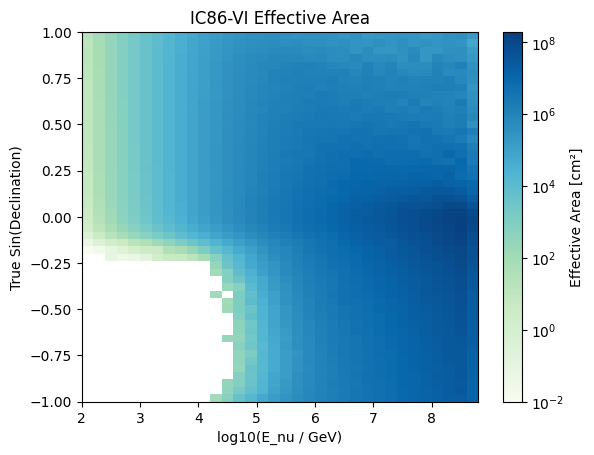

In [17]:
fig, ax = plt.subplots()
im = ax.pcolormesh(log_10_enu_edges, sin_nu_dec, eff_area, cmap='GnBu', norm=LogNorm())
ax.set_title('IC86-VI Effective Area')
ax.set_xlabel('log10(E_nu / GeV)')
ax.set_ylabel('True Sin(Declination)')
plt.colorbar(im, label='Effective Area [cm²]')
plt.show()

``effective_area.get_detection_prob_for_decnu`` returns the detection probability for each neutrino declination for a certain given true energy range. 

In [18]:
detection_prob = np.array(
    [effective_area.get_detection_prob_for_decnu(i, enu[0], enu[10], enu[0], enu[-1]) for i in nu_dec]
)

### Detection probability at the NGC 1068 declination

Here we evaluate the detection probability specifically at the NGC 1068 declination (-0.01°).
`get_detection_prob_for_decnu` integrates the effective area over a given energy range and normalises
it by the total energy range, returning the fraction of neutrinos in that band that are detectable.

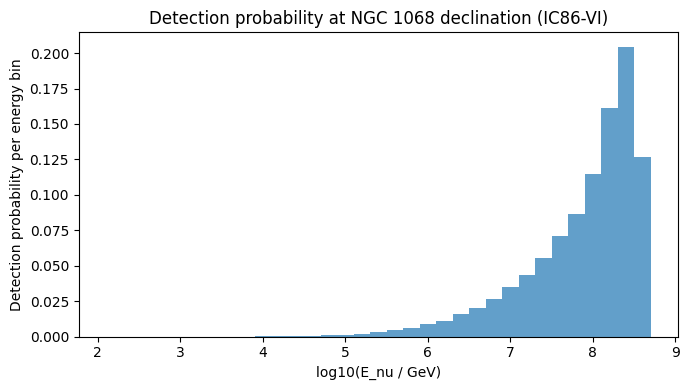

In [ ]:
ngc1068_dec = np.radians(-0.01)

# Per-energy-bin detection probability
det_prob_bins = np.array(
    [
        effective_area.get_detection_prob_for_decnu(ngc1068_dec, enu[i], enu[i + 1], enu[0], enu[-1])[0]
        for i in range(len(enu) - 1)
    ]
)

fig, ax = plt.subplots(figsize=(7, 4))
bin_centers = 0.5 * (log_10_enu[:-1] + log_10_enu[1:])
ax.bar(bin_centers, det_prob_bins, width=np.diff(log_10_enu), align='center', alpha=0.7)
ax.set_xlabel('log10(E_nu / GeV)')
ax.set_ylabel('Detection probability per energy bin')
ax.set_title('Detection probability at NGC 1068 declination (IC86-VI)')
plt.tight_layout()
plt.show()

### Effective area vs. energy at the NGC 1068 declination

The 2-D pcolormesh above showed the effective area at all declinations.
Here we extract the 1-D slice at the NGC 1068 declination.

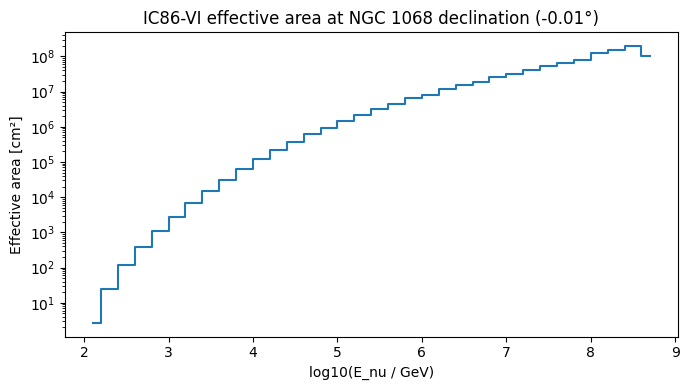

In [20]:
aeff_ngc1068 = effective_area.get_aeff_for_decnu(ngc1068_dec)

fig, ax = plt.subplots(figsize=(7, 4))
ax.step(log_10_enu, aeff_ngc1068, where='mid')
ax.set_xlabel('log10(E_nu / GeV)')
ax.set_ylabel('Effective area [cm²]')
ax.set_title('IC86-VI effective area at NGC 1068 declination (-0.01°)')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Smearing matrix marginal distributions

The 5-D smearing matrix has axes `(true_energy, true_declination, reco_energy, psi, angular_error)`.
Summing over different axes gives useful marginal distributions.
Below we plot the reconstructed-energy marginal (summed over true energy, true dec, psi, and angular error)
and the PSF marginal (summed over true energy, true dec, reco energy, and angular error).

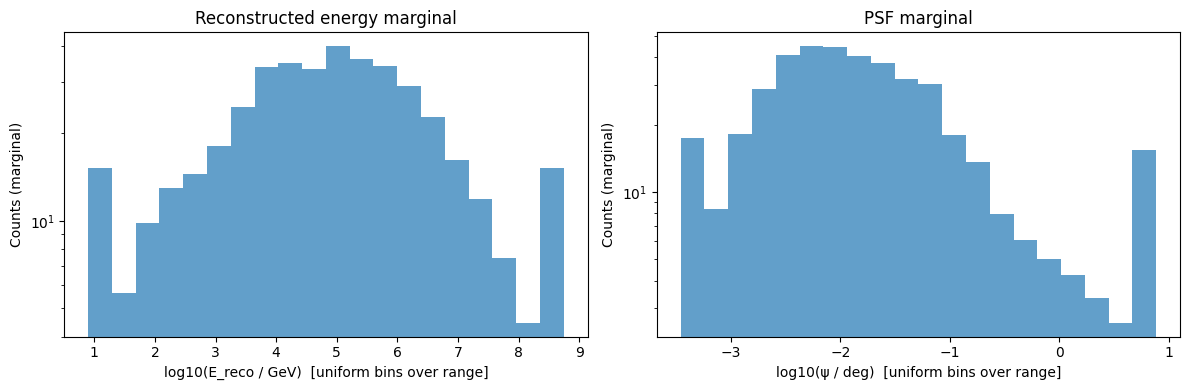

In [21]:
# smearing_matrix.histogram axes: (true_energy, true_dec, reco_energy, psi, angular_error)
# recon_probs (computed earlier) has shape (n_reco_e, n_psi, n_ang_err) after summing over
# true_energy and true_declination axes.

# 1-D reconstructed energy marginal (sum over psi and angular error)
reco_e_1d = recon_probs.sum(axis=(1, 2))
n_reco_e_bins = len(reco_e_1d)
# The reco energy bin edges vary per (true_e, true_dec) bin — use the global range as x-axis.
reco_e_edges = np.linspace(
    smearing_matrix.min_log10_reco_e,
    smearing_matrix.max_log10_reco_e,
    n_reco_e_bins + 1,
)

# 1-D PSF marginal (sum over reco_energy and angular error)
psf_1d = recon_probs.sum(axis=(0, 2))
n_psi_bins = len(psf_1d)
psi_edges = np.linspace(
    smearing_matrix.min_log10_psi,
    smearing_matrix.max_log10_psi,
    n_psi_bins + 1,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].stairs(reco_e_1d, reco_e_edges, fill=True, alpha=0.7)
axes[0].set_xlabel('log10(E_reco / GeV)  [uniform bins over range]')
axes[0].set_ylabel('Counts (marginal)')
axes[0].set_title('Reconstructed energy marginal')
axes[0].set_yscale('log')

axes[1].stairs(psf_1d, psi_edges, fill=True, alpha=0.7)
axes[1].set_xlabel('log10(ψ / deg)  [uniform bins over range]')
axes[1].set_ylabel('Counts (marginal)')
axes[1].set_title('PSF marginal')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

### How these IRFs feed into `create_analysis`

When you call ``create_analysis`` (as in the other tutorials), SkyLLH internally:

1. Retrieves the smearing and effective-area file paths from each dataset's aux data definitions (just as we did above with ``get_aux_data_definition``).
2. Constructs a ``PDSmearingMatrix`` per dataset season to build the signal spatial and energy PDFs.
3. Constructs a ``PDAeff`` per dataset season to compute the expected number of signal events for a given flux model.

The tutorial above therefore mirrors the internal data-flow of the analysis framework — what you see here is exactly what happens under the hood each time an analysis is initialised.